# Linear Regression

> 3 Types of LR

a. Simple LR
- One input and one output cols

b. Mutliple LR
- Multiple input cols and one output col

c. Polynomial LR
- When data is not linear

# Intuition

> Line : y = mx + c

> LR is a simple algo's who plot Best Fit Line(line which passes closely to all pts in data) on sort of linear data

> So LR is finding slope and y-intercept of line which are best fit to data

> Ex: package = m * cgpa + c
- m means weightage of cgpa on package

> So m tells weightage of x on y

> c is offset as if x become zero then also y will have val 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\100DaysOfMl\LinearRegression\placement_new.csv')

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [4]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [5]:
from sklearn.model_selection import train_test_split
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y, test_size=0.2, random_state=2)

In [6]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(x_tr, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
x_ts

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [8]:
y_ts

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [9]:
lr.predict(x_ts.iloc[0].values.reshape(1,1))

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package')

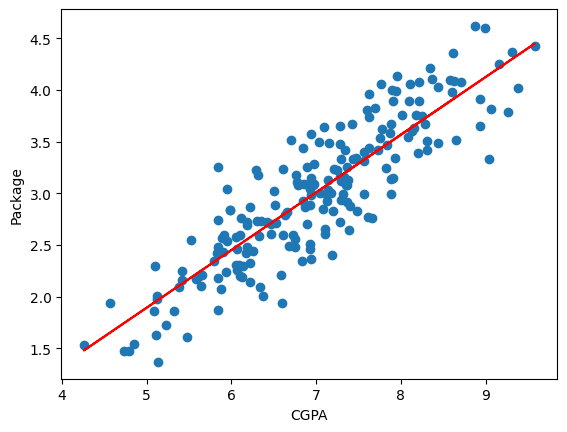

In [10]:
plt.scatter(x=df['cgpa'], y=df['package'])
plt.plot(x_tr, lr.predict(x_tr), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package')

This is a line which have slope and y-intercept as its eqn is : y = mx + c

In [11]:
m = lr.coef_

In [12]:
b = lr.intercept_

In [13]:
m * 8.58 + b

array([3.89111601])

# Solutn to LR(m,c vals)

1. Closed form soln -> Direct formula -> Technique called OLS(Ordinary Least Sq) -> Class : LR
2. Non-closed form soln -> Done using approximatn,integratn,etc -> Technique called Gradient Descent(used when data in higher dim) -> Class SGDRegression

> OLS formula:

<img src='img1.png'></img>

> Intuitn of OLS

<img src='img2.png'></img>

- Best fit line -> (m,b) val -> Minimum Error/loss fn
- Here Yi(actual val), Yi^(predcted val)
- di = (Yi - Yi^)
- E = sigma(Yi - Yi^)^2  -> min
- as Yi^ = mxi + b
- E = sigma(Yi^ - mxi - b)^2  -> Minimum
- To solve this we need to find m & b as it depend on them
- So to find maxima & minima(best m,b val) of gradient descent fn, we need to find partial derivative wrt m,b and put equal to 0 as at minima differentiatn is 0 which will give two equatn and we have two unknown

<img src='img3.png'></img>

# Making a class for LR

In [14]:
class MeraLR:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, x_train, y_train):
        
        num = 0
        den = 0

        for i in range(x_train.shape[0]):

            num = num + ((x_train[i] - x_train.mean()) * (y_train[i] - y_train.mean()))
            den = den + ((x_train[i] - x_train.mean()) * (x_train[i] - x_train.mean()))

        self.m = num / den
        self.b = y_train.mean() - (self.m * x_train.mean())
        print(self.m)
        print(self.b)
        

    def predict(self, x_test):
        return self.m * x_test + self.b

In [15]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\100DaysOfMl\LinearRegression\placement_new.csv')

In [16]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [17]:
x = df.iloc[:,0].values
y = df.iloc[:,1].values

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [19]:
x_train.shape

(160,)

In [20]:
lr = MeraLR()

In [21]:
lr.fit(x_train, y_train)

0.5579519734250721
-0.8961119222429152


In [24]:
y_pred = lr.predict(x_test)

In [26]:
y_test

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

# Regression metrics

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [29]:
print("MAE", mean_absolute_error(y_test, y_pred))

MAE 0.2884710931878174


In [30]:
print("MSE", mean_squared_error(y_test, y_pred))

MSE 0.12129235313495523


In [32]:
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE 0.3482705171773161


In [33]:
print("r2_score", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

r2_score 0.7807301475103842


In [34]:
x_test.shape

(40,)

In [35]:
# Adjusted r2 score
print("Adj r2", 1 - ((1-r2)*(40-1)/(40-1-1)))

Adj r2 0.7749598882343417


> Checking diff b/w adj r2 and r2

In [52]:
new_df = df.copy()
new_df['random_feat'] = np.random.random(200)

new_df = new_df[['cgpa','random_feat','package']]
new_df.head()

,cgpa,random_feat,package
0,6.89,0.641534,3.26
1,5.12,0.084533,1.98
2,7.82,0.176136,3.25
3,7.42,0.670418,3.67
4,6.94,0.158882,3.57


Text(0, 0.5, 'Package')

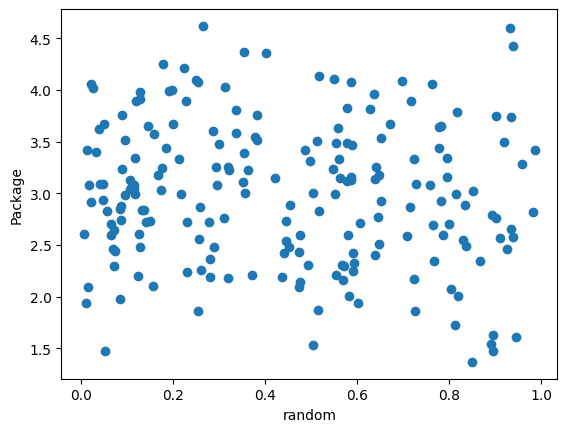

In [53]:
plt.scatter(x=new_df['random_feat'], y=new_df['package'])
plt.xlabel('random')
plt.ylabel('Package')

In [54]:
x = new_df.iloc[:,0:2]
y = new_df.iloc[:,-1]

In [55]:
x_tr, x_ts, y_tr, y_ts = train_test_split(x,y, test_size=0.2, random_state=2)

In [56]:
lr = LinearRegression()
lr.fit(x_tr, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
y_pred = lr.predict(x_ts)

In [58]:
print("r2_score", r2_score(y_ts, y_pred))
r2 = r2_score(y_ts, y_pred)

r2_score 0.7820874554828944


In [59]:
1 - ((1-r2)*(40-1)/(40-1-1))

0.7763529148377074